## IMPORT LIBRARIES

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## LOAD DATASET

In [47]:
df = pd.read_csv("RTA Dataset.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## Number of Rows and Columns

In [48]:
print("Shape of Dataset:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Shape of Dataset: (12316, 32)
Number of Rows: 12316
Number of Columns: 32


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [50]:
print(df.columns)

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')


## Count Accidents in Each Accident Severity Category

In [51]:
print(df["Accident_severity"].value_counts())

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


## Bar Chart of Accident Severity

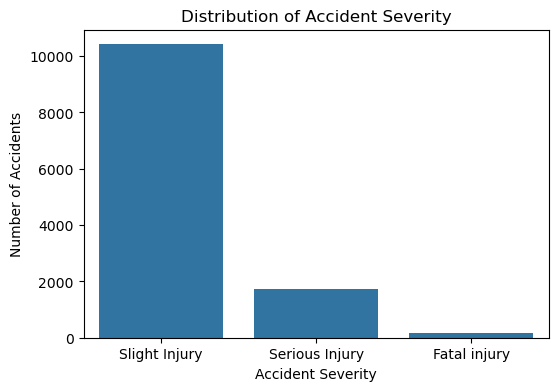

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Accident_severity", data=df)

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")

plt.show()

## Count Missing Values in Every Column

In [53]:
missing = df.isnull().sum()
print(missing)

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

## Columns with Highest Missing Values

In [54]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

Defect_of_vehicle              4427
Service_year_of_vehicle        3928
Work_of_casuality              3198
Fitness_of_casuality           2635
Type_of_vehicle                 950
Types_of_Junction               887
Driving_experience              829
Educational_level               741
Vehicle_driver_relation         579
Owner_of_vehicle                482
Lanes_or_Medians                385
Vehicle_movement                308
Area_accident_occured           239
Road_surface_type               172
Type_of_collision               155
Road_allignment                 142
Casualty_class                    0
Pedestrian_movement               0
Cause_of_accident                 0
Casualty_severity                 0
Age_band_of_casualty              0
Sex_of_casualty                   0
Time                              0
Road_surface_conditions           0
Number_of_casualties              0
Number_of_vehicles_involved       0
Weather_conditions                0
Light_conditions            

## Visualize Missing Values

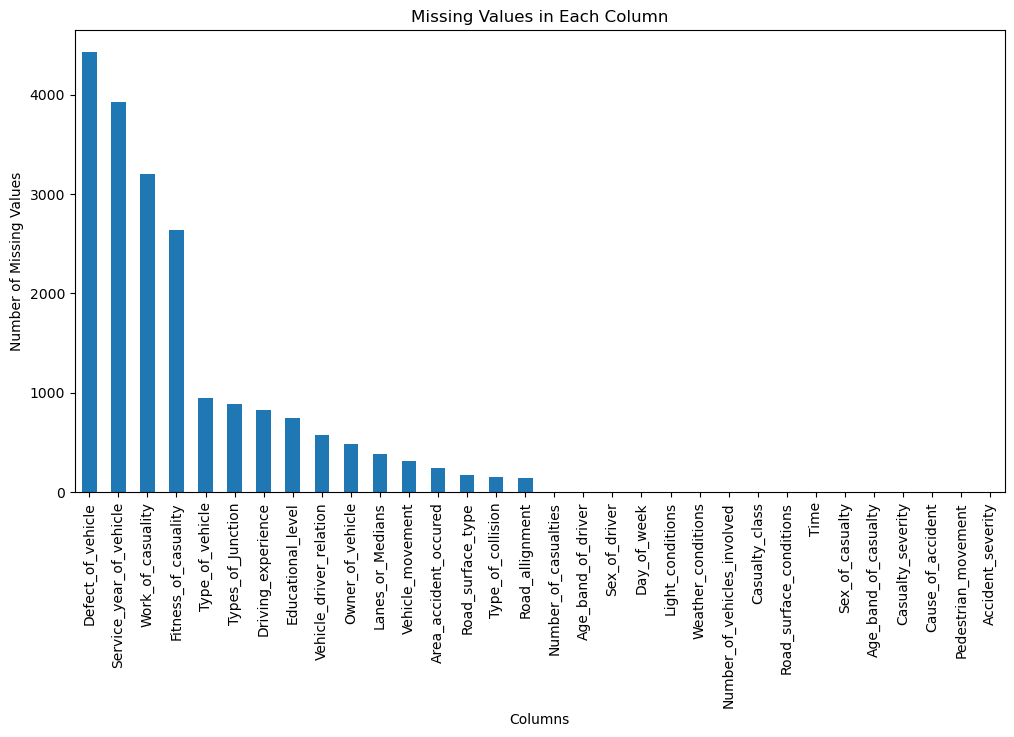

In [55]:
plt.figure(figsize=(12,6))

missing.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=90)

plt.show()

# DATA PREPROCESSING STEPS

## Fill Missing Values

## Check Missing Values Before Filling

In [56]:
# Total missing values before filling
print("Missing values before filling:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing values before filling:
Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                

In [57]:
# Fill categorical columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Unknown")

# Fill numerical columns
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())

In [58]:
# Check missing values after filling
print("Missing values after filling:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing values after filling:
Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_mo

# Feature Engineering and Feature Selection

## Convert Time into an Hour

In [59]:
# Convert Time column to datetime
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce")

# Create Hour column
df["Hour"] = df["Time"].dt.hour

# Check
df[["Time", "Hour"]].head()

,Time,Hour
0,1900-01-01 17:02:00,17
1,1900-01-01 17:02:00,17
2,1900-01-01 17:02:00,17
3,1900-01-01 01:06:00,1
4,1900-01-01 01:06:00,1


## Remove Original Time Column

In [60]:
df.drop("Time", axis=1, inplace=True)

print("Time column removed successfully.")

Time column removed successfully.


## Remove leakage columns

In [61]:
drop_columns = [
    "Casualty_class",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Casualty_severity",
    "Fitness_of_casuality",
    "Pedestrian_movement"
]

df = df.drop(columns=drop_columns, errors="ignore")

## Separate Features and Target

In [62]:
# Target Variable
y = df["Accident_severity"]

# Feature Variables
X = df.drop("Accident_severity", axis=1)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (12316, 25)
Target Shape: (12316,)


# Check Feature Names

In [63]:
print(X.columns)

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Work_of_casuality',
       'Cause_of_accident', 'Hour'],
      dtype='object')


## Encode All Categorical Feature Columns

In [64]:
# Create a dictionary to store encoders
label_encoders = {}

# Encode only categorical feature columns
for col in X.select_dtypes(include="object").columns:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(X[col].astype(str))
    
    label_encoders[col] = le

print("All categorical feature columns encoded successfully!")

All categorical feature columns encoded successfully!


## Encode Target Column Separately

In [65]:
# Separate encoder for target column
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

## Check Mapping of Target Classes

In [66]:
# Print target class mapping
for i, class_name in enumerate(target_encoder.classes_):
    print(f"{class_name} --> {i}")

Fatal injury --> 0
Serious Injury --> 1
Slight Injury --> 2


In [67]:
print(X.head())

print("\nEncoded Target:")
print(y[:10])

   Day_of_week  Age_band_of_driver  Sex_of_driver  Educational_level  \
0            1                   0              1                  0   
1            1                   1              1                  4   
2            1                   0              1                  4   
3            3                   0              1                  4   
4            3                   0              1                  4   

   Vehicle_driver_relation  Driving_experience  Type_of_vehicle  \
0                        0                   0                0   
1                        0                   3               11   
2                        0                   0                5   
3                        0                   2               11   
4                        0                   1               17   

   Owner_of_vehicle  Service_year_of_vehicle  Defect_of_vehicle  ...  \
0                 3                        3                  2  ...   
1                 3 

## Step 8 Train- test split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [69]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)


Training Features : (9852, 25)
Testing Features  : (2464, 25)
Training Target   : (9852,)
Testing Target    : (2464,)


## Check Class Distribution


In [70]:
print("Training Set Class Distribution")
print(pd.Series(y_train).value_counts())

print("\nTesting Set Class Distribution")
print(pd.Series(y_test).value_counts())

Training Set Class Distribution
2    8331
1    1394
0     127
Name: count, dtype: int64

Testing Set Class Distribution
2    2084
1     349
0      31
Name: count, dtype: int64


## Create Models

In [71]:
# Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

# Decision Tree
dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

## Check if Training is Completed

In [72]:
print(type(log_model))
print(type(dt_model))
print(type(rf_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Make Predictions

In [73]:
# Train Logistic Regression
log_model.fit(X_train, y_train)

# Train Decision Tree
dt_model.fit(X_train, y_train)

# Train Random Forest
rf_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [74]:
# Predictions
y_pred_log = log_model.predict(X_test)

y_pred_dt = dt_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [75]:
print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(len(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(9852, 25)
9852


## Calculate Accuracy

In [76]:
# Accuracy Scores
log_acc = accuracy_score(y_test, y_pred_log)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy :", round(log_acc,4))
print("Decision Tree Accuracy       :", round(dt_acc,4))
print("Random Forest Accuracy       :", round(rf_acc,4))

Logistic Regression Accuracy : 0.4903
Decision Tree Accuracy       : 0.7735
Random Forest Accuracy       : 0.847


## Classification Report

In [77]:
print("========== Logistic Regression ==========")
print(classification_report(y_test, y_pred_log))

print("========== Decision Tree ==========")
print(classification_report(y_test, y_pred_dt))

print("========== Random Forest ==========")
print(classification_report(y_test, y_pred_rf))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.02      0.32      0.04        31
           1       0.16      0.31      0.21       349
           2       0.87      0.52      0.65      2084

    accuracy                           0.49      2464
   macro avg       0.35      0.38      0.30      2464
weighted avg       0.76      0.49      0.58      2464

========== Decision Tree ==========
              precision    recall  f1-score   support

           0       0.10      0.13      0.11        31
           1       0.28      0.28      0.28       349
           2       0.87      0.87      0.87      2084

    accuracy                           0.77      2464
   macro avg       0.42      0.42      0.42      2464
weighted avg       0.78      0.77      0.77      2464

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1   

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Accuracy Comparison Bar Chart

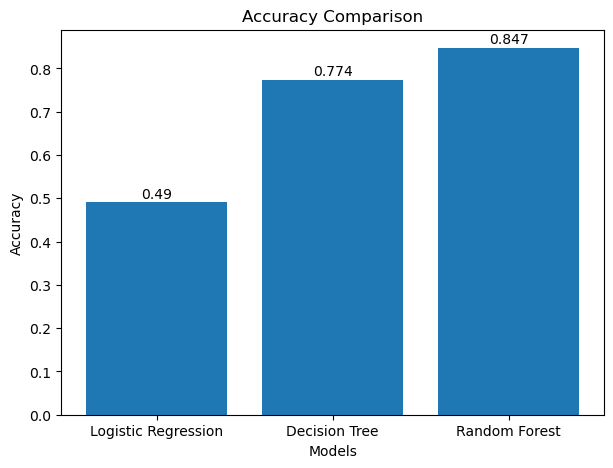

In [78]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracy = [
    log_acc,
    dt_acc,
    rf_acc
]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy):
    plt.text(i, v+0.01, str(round(v,3)), ha='center')

plt.show()

## Find Best Model

In [79]:
accuracy_dict = {
    "Logistic Regression": log_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}

best_model = max(accuracy_dict, key=accuracy_dict.get)

print("Best Model :", best_model)

Best Model : Random Forest


## Confusion Matrix (Best Model)

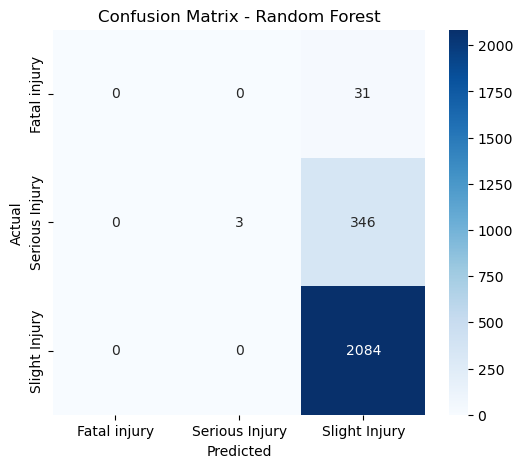

In [80]:
if best_model == "Logistic Regression":
    cm = confusion_matrix(y_test, y_pred_log)

elif best_model == "Decision Tree":
    cm = confusion_matrix(y_test, y_pred_dt)

else:
    cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Accuracy Table

In [81]:
result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_acc,
        dt_acc,
        rf_acc
    ]
})

print(result)

                 Model  Accuracy
0  Logistic Regression  0.490260
1        Decision Tree  0.773539
2        Random Forest  0.846997


## Feature Importance

In [82]:
# Create DataFrame of Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10 Features
print(feature_importance.head(10))


                        Feature  Importance
24                         Hour    0.095402
20         Number_of_casualties    0.085443
23            Cause_of_accident    0.069905
0                   Day_of_week    0.065786
6               Type_of_vehicle    0.063798
5            Driving_experience    0.050863
10        Area_accident_occured    0.050595
19  Number_of_vehicles_involved    0.050404
1            Age_band_of_driver    0.048844
13            Types_of_Junction    0.045763


## Plot Top 10 Important Features

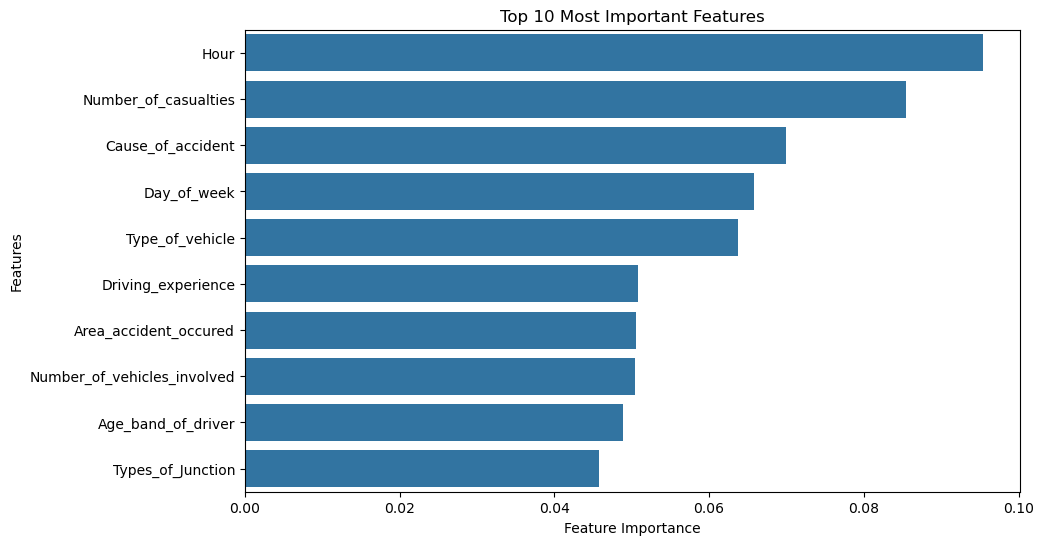

In [83]:
# Top 10 Features
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

# PREDICTION ON NEW SAMPLE DATA 

In [84]:
# Select one sample from the testing set
sample = X_test.iloc[[0]]

In [85]:
prediction = rf_model.predict(sample)

In [86]:
predicted_label = target_encoder.inverse_transform(prediction)

print("Predicted Severity :", predicted_label[0])

Predicted Severity : Slight Injury


In [87]:
actual = y_test[0]

actual_label = target_encoder.inverse_transform([actual])

print("Actual Severity :", actual_label[0])

Actual Severity : Slight Injury


## Compare Prediction and Actual

In [88]:
print("Predicted Severity :", predicted_label[0])
print("Actual Severity    :", actual_label[0])

if predicted_label[0] == actual_label[0]:
    print("\nPrediction is Correct")
else:
    print("\nPrediction is Incorrect")

Predicted Severity : Slight Injury
Actual Severity    : Slight Injury

Prediction is Correct
